# EDA of the PassivUK temperature time series dataset

In [ ]:
import os
from datetime import datetime
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.dates import DayLocator, DateFormatter, HourLocator

## Load data

In [ ]:
data_path = "data/PST_Data_20260220"
temperature_files = [f for f in glob(os.path.join(data_path, "*.csv")) if "Events" not in f]
events_files = [f for f in glob(os.path.join(data_path, "*_Events_*_*.csv"))]

In [ ]:
# House:
house_index = 1
house_id = temperature_files[house_index].split("/")[-1].split("_")[0]
house_df = pd.read_csv(temperature_files[house_index])

In [ ]:
house_id

# Preprocessing

In [ ]:
# Convert time to datetime
house_df["Datetime"] = [datetime.strptime(t, '%Y-%m-%d %H:%M') for t in house_df['Time (UTC)'].values]

In [ ]:
house_temp_df =  house_df.reindex(columns = ["Room temperature (Zone 1) (°C)",
                                             "Setpoint temperature (Zone 1) (°C)",
                                             "Flow temperature setpoint (°C)",
                                             "Flow temperature (°C)",
                                             "Return temperature (°C)",
                                             "External temperature (°C)"])            
house_temp_df.describe().transpose()

In [ ]:
house_df

# Plot house time series

In [ ]:
colours = ["#dc267f", "#ffb000", "#1589e8", "#631ff3", "#fe5100"] # - IBM colourblind palette

In [ ]:
num_days = int(len(house_df)/(12*24))
num_weeks = int(num_days/7)

In [ ]:
datapoints_in_week = (12*24)*7
datapoints_in_day = (12*24)

### Plot by week

In [ ]:
def calc_num_weeks_and_days(df,datapoints_in_hour):
    """Calculate the number of weeks and days in the dataset; as well as the number of datapoints in each week and day"""
    datapoints_in_day = datapoints_in_hour*24
    datapoints_in_week = datapoints_in_day*7
    num_days = int(len(df)/(datapoints_in_day))
    num_weeks = int(num_days/7)
    
    return num_weeks, num_days, datapoints_in_week, datapoints_in_day


def configure_plotting_vars(plot_weeks, week_to_plot):
    """Configure number of plots and required offset"""
    if plot_weeks and week_to_plot is not None:
        plots = [week_to_plot] # num_to_plot = 1  # Plot one week
        offset = 0
    elif not plot_weeks and week_to_plot is not None:
        plots = range(7)  # Plot seven days
        offset = datapoints_in_week*week_to_plot  # Offset only needed if plotting days for a specific week
    else:  # NOT using week_to_plot (i.e. want all days or all weeks in dataset)
        plots = range(num_weeks) if plot_weeks else range(num_days)
        offset = 0
    
    slice_length = datapoints_in_week if plot_weeks else datapoints_in_day

    return plots, offset, slice_length

_IncompleteInputError: incomplete input (3658572158.py, line 11)

In [ ]:
def plot_temp_data(df, plot_weeks, week_to_plot=None):
    """Plot the temperature data by either week or day

    Args:


    Returns:
        Plots of the temperature data by week or day
    """

    # Calculate number or weeks
    num_weeks, num_days, datapoints_in_week, datapoints_in_day = calc_num_weeks_and_days(df, 12)

    # Configure number of plots and required offset
    plots, offset, slice_length = configure_plotting_vars(plot_weeks, week_to_plot)

    for i in plots:
        # Slice by time (week or day)
        start_index = offset + i*slice_length
        end_index = offset + i*slice_length + slice_length

        # Get data
        dates = house_df["Datetime"][start_index:end_index]
        room_temp = house_df["Room temperature (Zone 1) (°C)"][start_index:end_index]
        user_setpoint = house_df["Setpoint temperature (Zone 1) (°C)"][start_index:end_index]
        flow_temp = house_df["Flow temperature (°C)"][start_index:end_index]
        hot_water_temp = house_df["Hot water temperature (°C)"][start_index:end_index]
        hot_water_setpoint = house_df["Hot water setpoint (°C)"][start_index:end_index]
        # flow_setpoint = house_df["Flow temperature setpoint (°C)"][start_index:end_index]
        ext_temp_bool = True
        try: 
            ext_temp = house_df["External temperature (°C)"][start_index:end_index]
        except:  # noqa: E722
            ext_temp_bool = False
        space_heating_bool = False
        if space_heating_bool:
            space_heating_on = house_df["Space heating (0/1)"][start_index:end_index]
            zone1_heating_on = house_df["Zone 1 heating (0/1)"][start_index:end_index]
            zone2 = True
            try:
                zone2_heating_on = house_df["Zone 2 heating (0/1)"][start_index:end_index]
            except:  # noqa: E722
                zone2 = False
        tariff = house_df["Tariff rate (p/kWh)"][start_index:end_index]

        # Make subfigs
        if space_heating_bool:
            if zone2:
                fig, (temp_plot, space_heating_plot, zone1_heating_plot, zone2_heating_plot) = plt.subplots(4, 1, sharex=True, height_ratios=[9, 1, 1, 1], figsize=(12,6), layout="tight")
            else:
                fig, (temp_plot, space_heating_plot, zone1_heating_plot) = plt.subplots(3, 1, sharex=True, height_ratios=[9, 1, 1], figsize=(12,6), layout="tight")
        else:
            fig, (temp_plot, hot_water_plot, tariff_plot) = plt.subplots(3, 1, sharex=True, height_ratios=[5, 5, 2], figsize=(15,6), layout="tight")
        plt.xlim(house_df["Datetime"][start_index],house_df["Datetime"][end_index])
        if plot_weeks:
            fig.suptitle(f"House: {house_id}, \
                    Week index: {i} \
                    Week commencing: {dates[start_index].day}/{dates[start_index].month}/{dates[start_index].year}")
            plt.xlabel("Date")
            
            ax = fig.gca()
            ax.xaxis.set_major_locator(DayLocator(interval=1))
            ax.xaxis.set_major_formatter(DateFormatter('%d/%m/%y'))
        else:
            fig.suptitle(f"House: {house_id}, \
            Week index: {week_to_plot} \
            Date: {dates[start_index].day}/{dates[start_index].month}/{dates[start_index].year}")
            plt.xlabel("Time of day")
            ax = fig.gca()
            ax.xaxis.set_major_locator(HourLocator(interval=1))
            ax.xaxis.set_major_formatter(DateFormatter('%H:%M'))

        # Plot temperature variations
        temp_plot.plot(dates, room_temp, label="Room temperature", c=colours[0])
        temp_plot.plot(dates, user_setpoint, label="User setpoint", c=colours[1])
        temp_plot.plot(dates, flow_temp, label="Flow temperature", c=colours[2])
        
        # plt.plot(dates, flow_setpoint, label="Flow setpoint")
        if ext_temp_bool:
            temp_plot.plot(dates, ext_temp, label="External temperature", c=colours[3])
        temp_plot.grid(visible=True, axis="x")
        temp_plot.set_ylabel("Temperature (°C)")
        temp_plot.legend(bbox_to_anchor=(1.0, 0.5))

        # Hot water plot
        hot_water_plot.plot(dates, hot_water_temp, label="Hot water temperature",c=colours[0])
        hot_water_plot.plot(dates, hot_water_setpoint, label = "Hot water setpoint", c=colours[1])
        hot_water_plot.plot(dates, flow_temp, label="Flow temperature", c=colours[2])
        hot_water_plot.grid(visible=True, axis="x")
        hot_water_plot.set_ylabel("Temperature (°C)")
        hot_water_plot.legend(bbox_to_anchor=(1.0, 0.5))

        if space_heating_bool:
            # Plot space heating on/off (if heat pump on for space heating)
            space_heating_plot.plot(dates, space_heating_on, c=colours[4])
            space_heating_plot.fill_between(dates, space_heating_on, np.zeros(len(dates)), color=colours[4])
            space_heating_plot.grid(visible=True, axis="x")
            space_heating_plot.set_ylabel("Space")

            # Plot heating on/off in zone
            zone1_heating_plot.plot(dates, zone1_heating_on, c=colours[4])
            zone1_heating_plot.fill_between(dates, zone1_heating_on, np.zeros(len(dates)), color=colours[4])
            zone1_heating_plot.grid(visible=True, axis="x")
            zone1_heating_plot.set_ylabel("Zone 1")

            if zone2:
                zone2_heating_plot.plot(dates, zone2_heating_on, c=colours[4])
                zone2_heating_plot.fill_between(dates, zone2_heating_on, np.zeros(len(dates)), color=colours[4])
                zone2_heating_plot.grid(visible=True, axis="x")
                zone2_heating_plot.set_ylabel("Zone 1")
        
        # Tariff plot
        tariff_plot.plot(dates, tariff, color=colours[4])
        tariff_plot.grid(visible=True, axis="x")
        tariff_plot.set_ylabel("Tariff rate (p/kWh)")
        tariff_plot.set_ylim(house_df["Tariff rate (p/kWh)"].min()-0.5, house_df["Tariff rate (p/kWh)"].max()+0.5)
        plt.show()

In [197]:
num_days = int(len(house_df)/(12*24))
num_weeks = int(num_days/7)

In [198]:
num_weeks

19

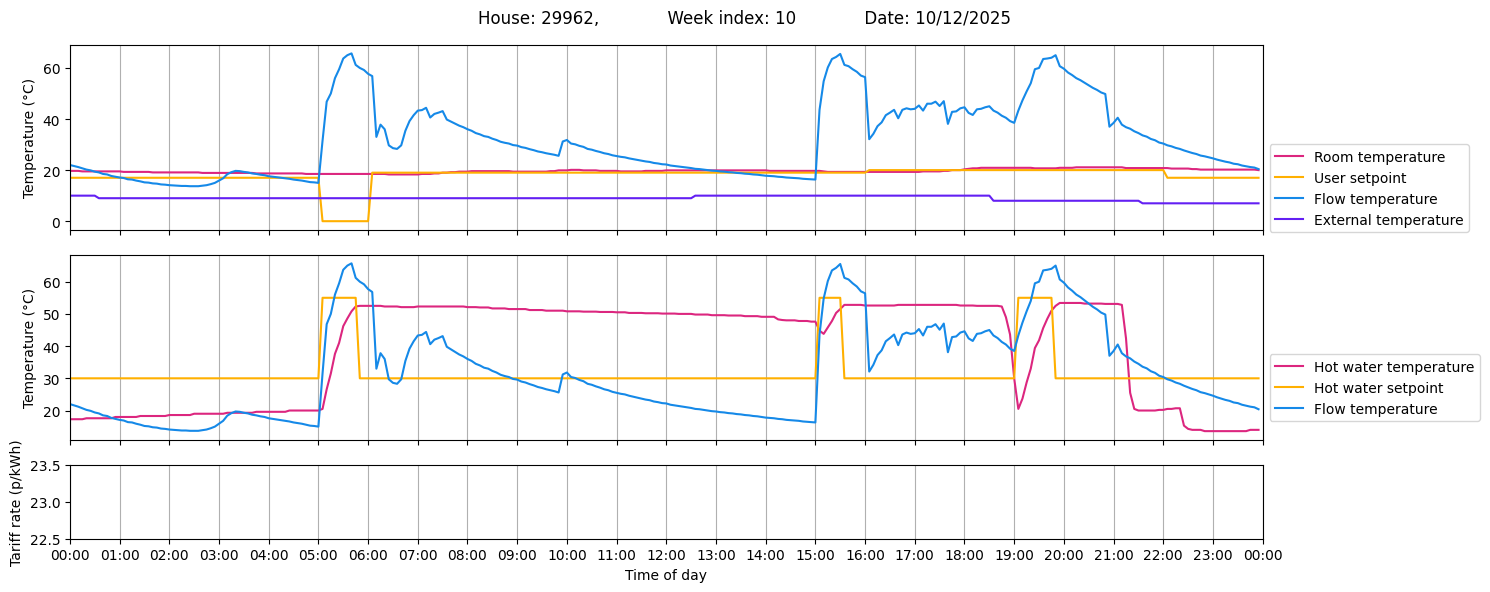

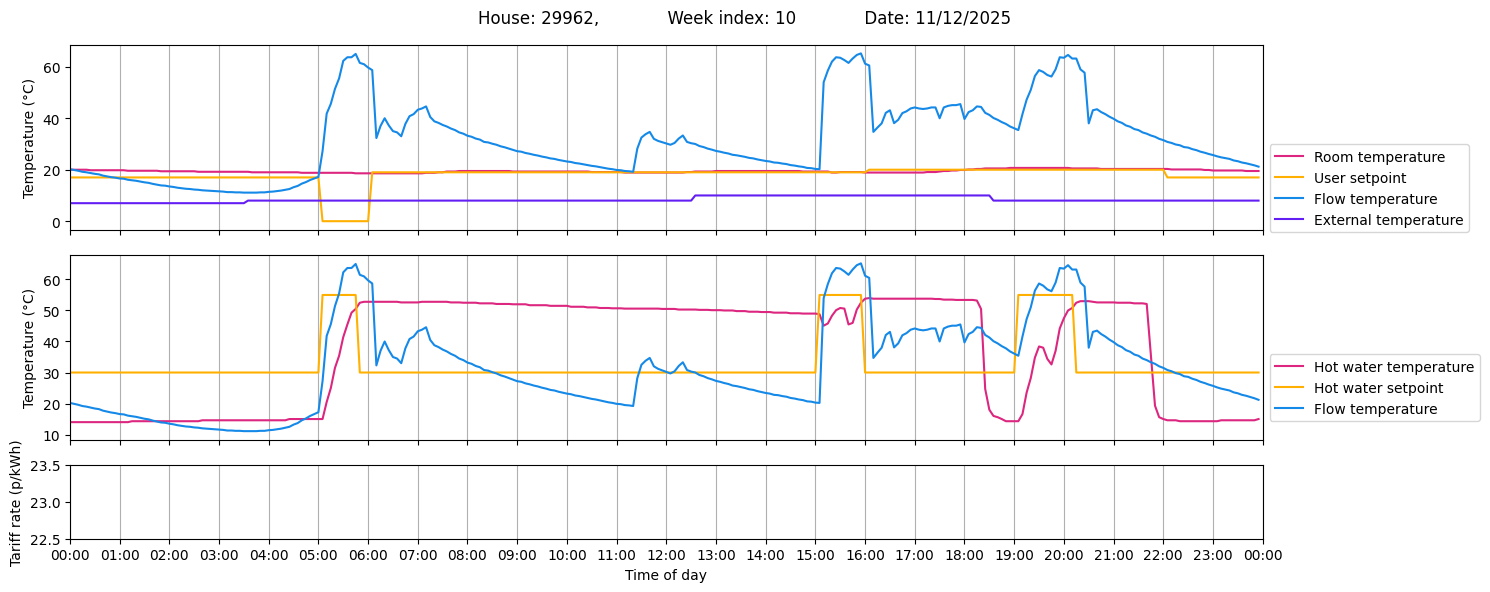

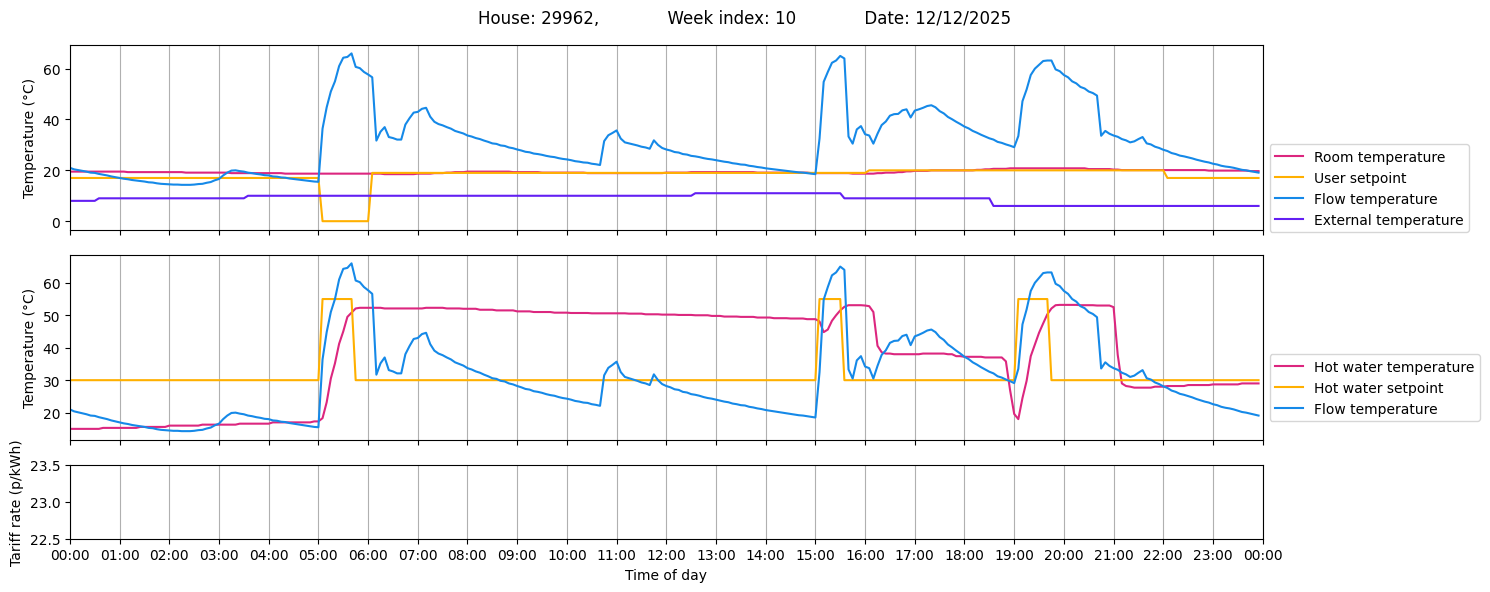

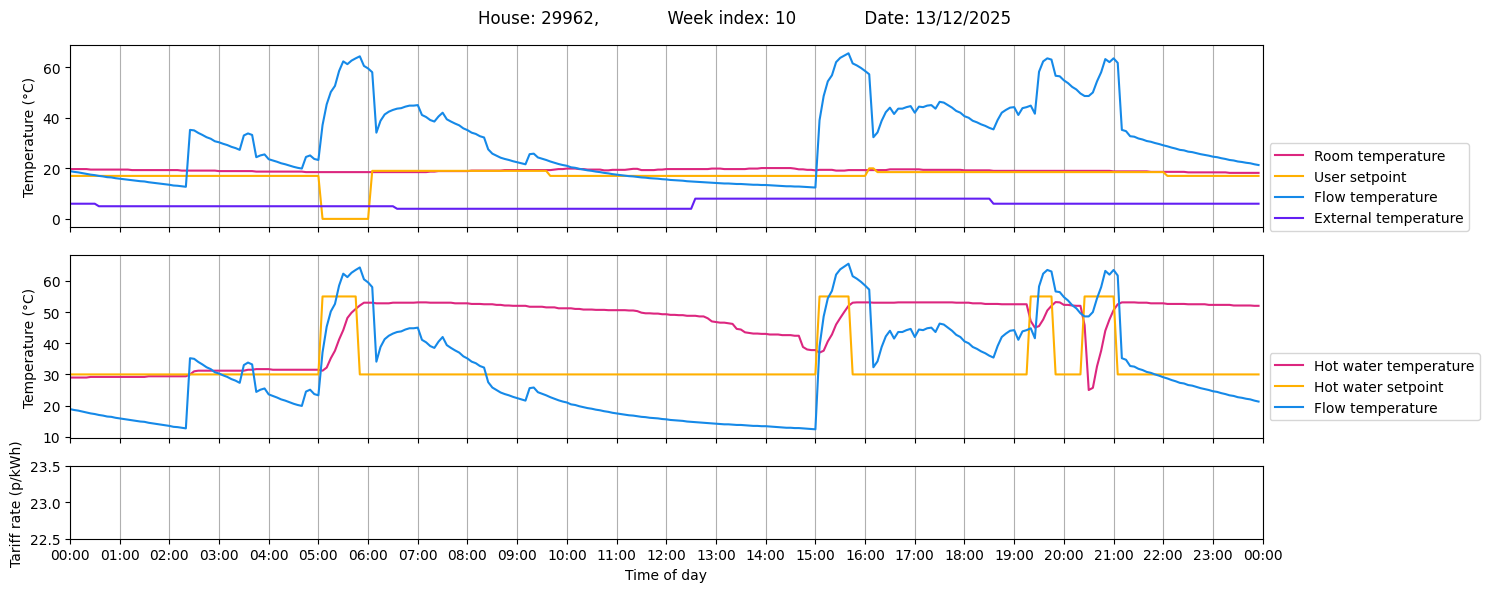

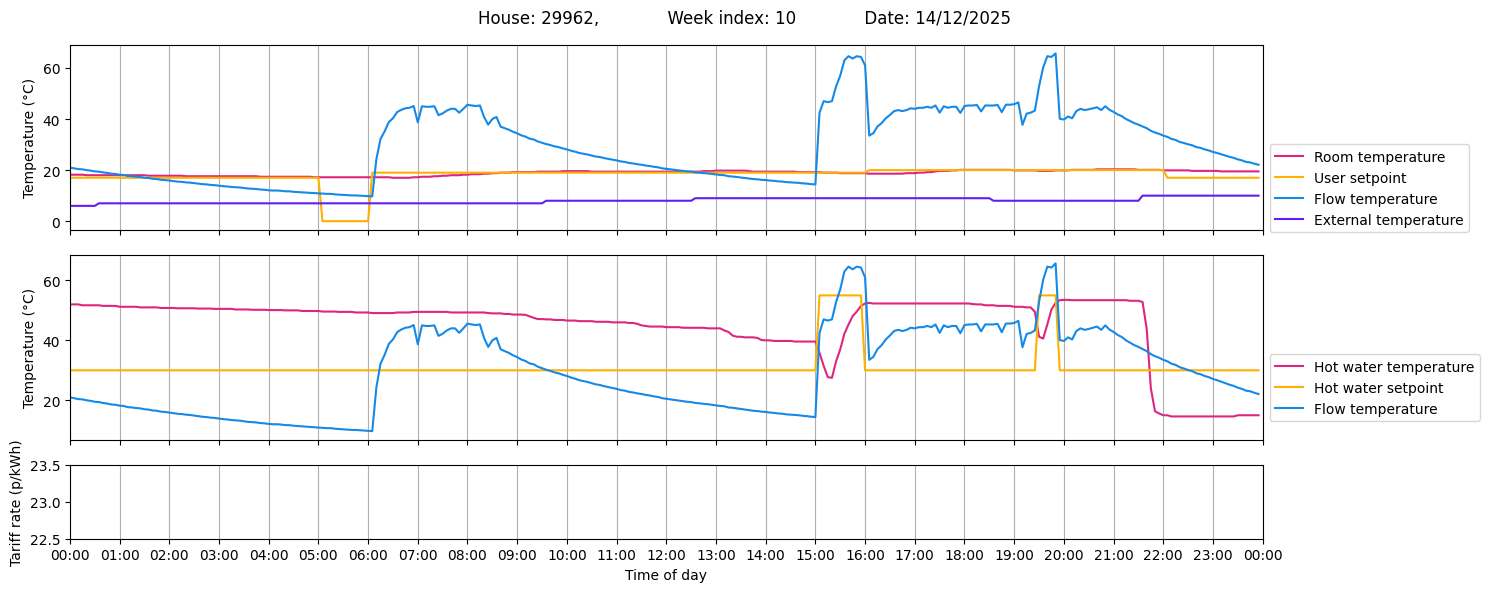

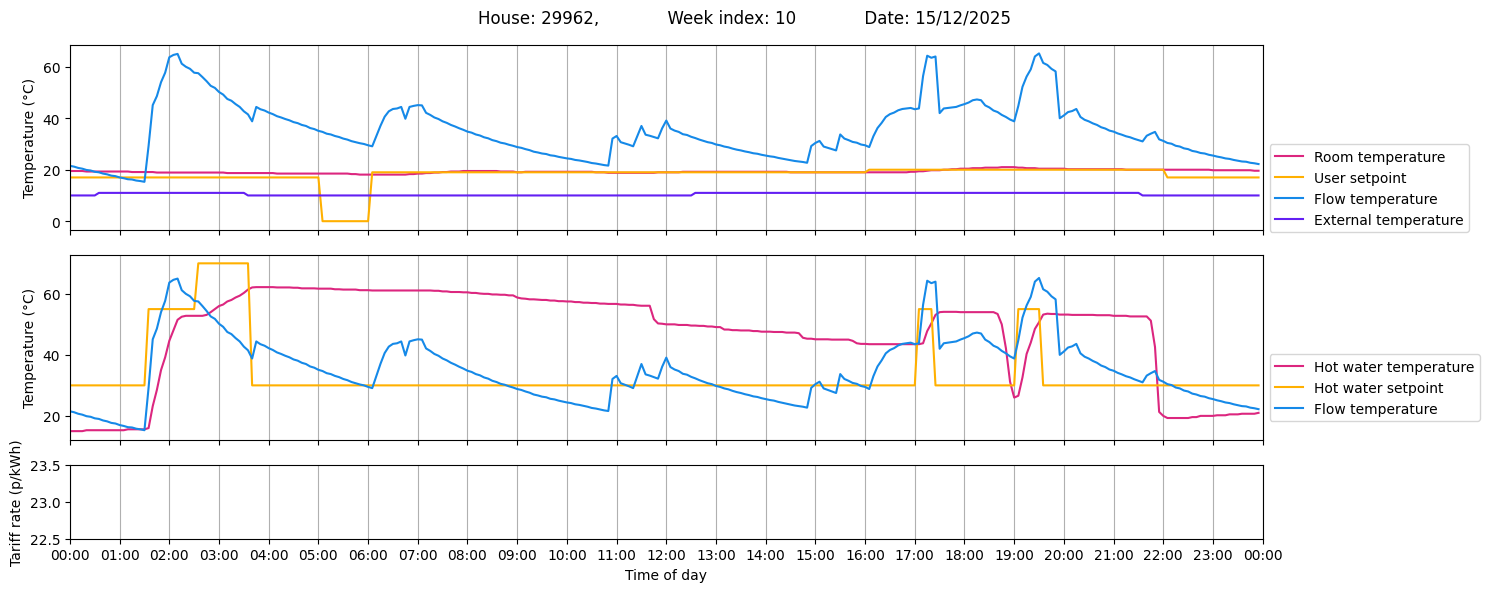

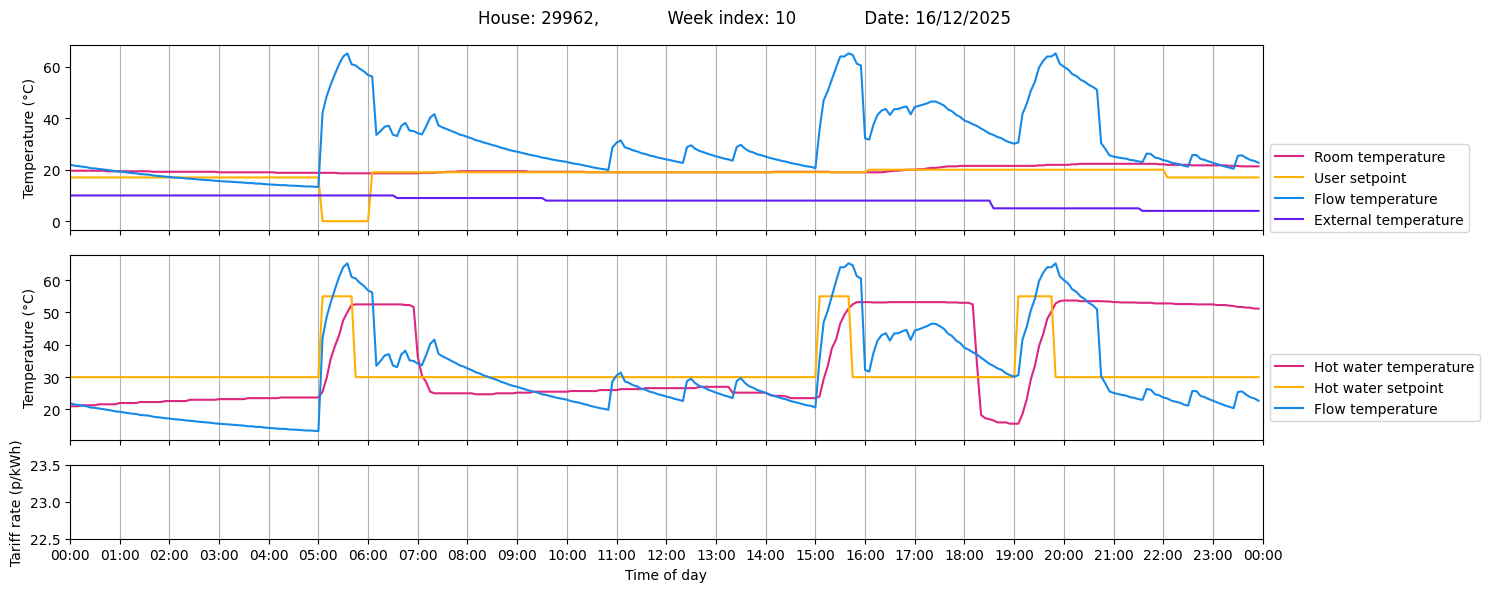

In [200]:
plot_temp_data(house_df, False, 10)

In [ ]:
plot_temp_data(house_df, True, 0)

In [ ]:
num_days = int(len(house_df)/(12*24))
num_weeks = int(num_days/7)

In [ ]:
for i in range(num_weeks):
    # Slice by week
    start_index = i*datapoints_in_week
    end_index = i*datapoints_in_week + datapoints_in_week

    dates = house_df["Datetime"][start_index:end_index]
    room_temp = house_df["Room temperature (Zone 1) (°C)"][start_index:end_index]
    user_setpoint = house_df["Setpoint temperature (Zone 1) (°C)"][start_index:end_index]
    flow_temp = house_df["Flow temperature (°C)"][start_index:end_index]
    hot_water_temp = house_df["Hot water temperature (°C)"][start_index:end_index]
    hot_water_setpoint = house_df["Hot water setpoint (°C)"][start_index:end_index]
    # flow_setpoint = house_df["Flow temperature setpoint (°C)"][start_index:end_index]
    ext_temp_bool = True
    try: 
        ext_temp = house_df["External temperature (°C)"][start_index:end_index]
    except:  # noqa: E722
        ext_temp_bool = False
    space_heating_bool = False
    if space_heating_bool:
        space_heating_on = house_df["Space heating (0/1)"][start_index:end_index]
        zone1_heating_on = house_df["Zone 1 heating (0/1)"][start_index:end_index]
        zone2 = True
        try:
            zone2_heating_on = house_df["Zone 2 heating (0/1)"][start_index:end_index]
        except:  # noqa: E722
            zone2 = False
    tariff = house_df["Tariff rate (p/kWh)"][start_index:end_index]

    # Make subfigs
    if space_heating_bool:
        if zone2:
            fig, (temp_plot, space_heating_plot, zone1_heating_plot, zone2_heating_plot) = plt.subplots(4, 1, sharex=True, height_ratios=[9, 1, 1, 1], figsize=(12,6), layout="tight")
        else:
            fig, (temp_plot, space_heating_plot, zone1_heating_plot) = plt.subplots(3, 1, sharex=True, height_ratios=[9, 1, 1], figsize=(12,6), layout="tight")
    else:
        fig, (temp_plot, hot_water_plot, tariff_plot) = plt.subplots(3, 1, sharex=True, height_ratios=[5, 5, 2], figsize=(15,6), layout="tight")
    
    fig.suptitle(f"House: {house_id}, \
              Week index: {i} \
              Week commencing: {dates[start_index].day}/{dates[start_index].month}/{dates[start_index].year}")
    plt.xlabel("Date")
    plt.xlim(house_df["Datetime"][start_index],house_df["Datetime"][end_index])
    ax = fig.gca()
    ax.xaxis.set_major_locator(DayLocator(interval=1))
    ax.xaxis.set_major_formatter(DateFormatter('%d/%m/%y'))

    # Plot temperature variations
    temp_plot.plot(dates, room_temp, label="Room temperature", c=colours[0])
    temp_plot.plot(dates, user_setpoint, label="User setpoint", c=colours[1])
    temp_plot.plot(dates, flow_temp, label="Flow temperature", c=colours[2])
    
    # plt.plot(dates, flow_setpoint, label="Flow setpoint")
    if ext_temp_bool:
        temp_plot.plot(dates, ext_temp, label="External temperature", c=colours[3])
    temp_plot.grid(visible=True, axis="x")
    temp_plot.set_ylabel("Temperature (°C)")
    temp_plot.legend(bbox_to_anchor=(1.0, 0.5))

    # Hot water plot
    hot_water_plot.plot(dates, hot_water_temp, label="Hot water temperature",c=colours[0])
    hot_water_plot.plot(dates, hot_water_setpoint, label = "Hot water setpoint", c=colours[1])
    hot_water_plot.plot(dates, flow_temp, label="Flow temperature", c=colours[2])
    hot_water_plot.grid(visible=True, axis="x")
    hot_water_plot.set_ylabel("Temperature (°C)")
    hot_water_plot.legend(bbox_to_anchor=(1.0, 0.5))

    if space_heating_bool:
        # Plot space heating on/off (if heat pump on for space heating)
        space_heating_plot.plot(dates, space_heating_on, c=colours[4])
        space_heating_plot.fill_between(dates, space_heating_on, np.zeros(len(dates)), color=colours[4])
        space_heating_plot.grid(visible=True, axis="x")
        space_heating_plot.set_ylabel("Space")

        # Plot heating on/off in zone
        zone1_heating_plot.plot(dates, zone1_heating_on, c=colours[4])
        zone1_heating_plot.fill_between(dates, zone1_heating_on, np.zeros(len(dates)), color=colours[4])
        zone1_heating_plot.grid(visible=True, axis="x")
        zone1_heating_plot.set_ylabel("Zone 1")

        if zone2:
            zone2_heating_plot.plot(dates, zone2_heating_on, c=colours[4])
            zone2_heating_plot.fill_between(dates, zone2_heating_on, np.zeros(len(dates)), color=colours[4])
            zone2_heating_plot.grid(visible=True, axis="x")
            zone2_heating_plot.set_ylabel("Zone 1")
    
    # Tariff plot
    tariff_plot.plot(dates, tariff, color=colours[4])
    tariff_plot.grid(visible=True, axis="x")
    tariff_plot.set_ylabel("Tariff rate (p/kWh)")
    tariff_plot.set_ylim(house_df["Tariff rate (p/kWh)"].min()-0.5, house_df["Tariff rate (p/kWh)"].max()+0.5)
    plt.show()

In [ ]:
house_df["Tariff rate (p/kWh)"].min()

### Plot by day

In [ ]:
week_to_plot = 13 # Should be an int <= num_weeks corresponding to which week from the above graphs to zoom in on
for i in range(7):
    #  Slice by day
    start_index = datapoints_in_week*week_to_plot + i*datapoints_in_day
    end_index = datapoints_in_week*week_to_plot + i*datapoints_in_day + datapoints_in_day

    dates = house_df["Datetime"][start_index:end_index]
    room_temp = house_df["Room temperature (Zone 1) (°C)"][start_index:end_index]
    user_setpoint = house_df["Setpoint temperature (Zone 1) (°C)"][start_index:end_index]
    flow_temp = house_df["Flow temperature (°C)"][start_index:end_index]
    # flow_setpoint = house_df["Flow temperature setpoint (°C)"][start_index:end_index]
    ext_temp = True
    try: 
        ext_temp = house_df["External temperature (°C)"][start_index:end_index]
    except:  # noqa: E722
        ext_temp = False
    space_heating_on = house_df["Space heating (0/1)"][start_index:end_index]
    zone1_heating_on = house_df["Zone 1 heating (0/1)"][start_index:end_index]
    zone2 = True
    try:
        zone2_heating_on = house_df["Zone 2 heating (0/1)"][start_index:end_index]
    except:  # noqa: E722
        zone2 = False

    # Make subfigs
    if zone2:
        fig, (temp_plot, space_heating_plot, zone1_heating_plot, zone2_heating_plot) = plt.subplots(4, 1, sharex=True, height_ratios=[9, 1, 1, 1], figsize=(12,6), layout="tight")
    else:
        fig, (temp_plot, space_heating_plot, zone1_heating_plot) = plt.subplots(3, 1, sharex=True, height_ratios=[9, 1, 1], figsize=(12,6), layout="tight")
    fig.suptitle(f"House: {house_id}, \
              Week index: {week_to_plot} \
              Date: {dates[start_index].day}/{dates[start_index].month}/{dates[start_index].year}")
    plt.xlabel("Time of day")
    plt.xlim(house_df["Datetime"][start_index],house_df["Datetime"][end_index])
    ax = fig.gca()
    ax.xaxis.set_major_locator(HourLocator(interval=1))
    ax.xaxis.set_major_formatter(DateFormatter('%H:%M'))

    # Plot temperature variations
    temp_plot.plot(dates, room_temp, label="Room temperature", c=colours[0])
    temp_plot.plot(dates, user_setpoint, label="User setpoint", c=colours[1])
    temp_plot.plot(dates, flow_temp, label="Flow temperature", c=colours[2])
    # plt.plot(dates, flow_setpoint, label="Flow setpoint")
    if ext_temp:
        temp_plot.plot(dates, ext_temp, label="External temperature", c=colours[3])
    temp_plot.grid(visible=True, axis="x")
    temp_plot.set_ylabel("Temperature (°C)")
    temp_plot.legend()

    # Plot space heating on/off (if heat pump on for space heating)
    space_heating_plot.plot(dates, space_heating_on, c=colours[4])
    space_heating_plot.fill_between(dates, space_heating_on, np.zeros(len(dates)), color=colours[4])
    space_heating_plot.grid(visible=True, axis="x")
    space_heating_plot.set_ylabel("Space")

    # Plot heating on/off in zone
    zone1_heating_plot.plot(dates, zone1_heating_on, c=colours[4])
    zone1_heating_plot.fill_between(dates, zone1_heating_on, np.zeros(len(dates)), color=colours[4])
    zone1_heating_plot.grid(visible=True, axis="x")
    zone1_heating_plot.set_ylabel("Zone 1")

    if zone2:
        zone2_heating_plot.plot(dates, zone2_heating_on, c=colours[4])
        zone2_heating_plot.fill_between(dates, zone2_heating_on, np.zeros(len(dates)), color=colours[4])
        zone2_heating_plot.grid(visible=True, axis="x")
        zone2_heating_plot.set_ylabel("Zone 1")
    plt.show()